## Synthetic Control

In [2]:
!pip install -r "requirements.txt"

# import necessary libraries and functions
from did_analysis_functions import *
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import datetime as dt
import geopandas as gpd
from sdid import SyntheticDiffInDiff


  Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached pandas-3.0.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached numpy-2.4.4-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached datetime-6.0-py3-none-any.whl.metadata (34 kB)
  Using cached geopandas-1.1.3-py3-none-any.whl.metadata (2.3 kB)
  Using cached sdid-0.3.5-py3-none-any.whl.metadata (15 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.1.1-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached zope_interface-8.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (45 kB)
  Using cached py

### Load Data

In [7]:
collisions_ca_path = r"../data/clean_data/California_Collisions_Clean.csv"
collisions_ca = load_data(collisions_ca_path)

California_Collisions_Clean.csv converted to dataframe.


## Process Data before Modeling

In [8]:
# restructure data
monthly_did_data = (collisions_ca.groupby(['Agency', 'year_month'])
             .size()
             .reset_index(name='crashes'))

monthly_did_data['year_month'] = pd.to_datetime(monthly_did_data['year_month'])
monthly_did_data['year_month'] = monthly_did_data['year_month'].astype('period[M]')
monthly_did_data['year_month'] = monthly_did_data['year_month'].dt.to_timestamp()

monthly_did_data = monthly_did_data[monthly_did_data['Agency'].notna()]

In [9]:
TREATMENT_DATE = pd.Timestamp('2014-04-01')  #Closest date after March 18th, 2014
TREATED_CITY   = 'San Francisco'

monthly_did_data['post'] = (monthly_did_data['year_month'] >= TREATMENT_DATE).astype(int)
monthly_did_data['treat'] = (monthly_did_data['Agency'] == TREATED_CITY).astype(int)

###  Find Control Cities

In [15]:
control_cities = monthly_did_data['Agency'].unique

### Convert Year Month Variable to a numeric counter

In [16]:
# Convert time formats
monthly_did_data['time_numeric'] = (
    (monthly_did_data['year_month'].dt.year - monthly_did_data['year_month'].dt.year.min()) * 12 +
    (monthly_did_data['year_month'].dt.month - monthly_did_data['year_month'].dt.month.min())
)

min_year = monthly_did_data['year_month'].dt.year.min()
min_month = monthly_did_data['year_month'].dt.month.min()
treatment_numeric = (2014 - min_year) * 12 + (3 - min_month)

## Create Model

In [17]:
model = SyntheticDiffInDiff(
    data        = monthly_did_data,
    outcome_col = 'crashes',
    times_col   = 'time_numeric',
    units_col   = 'Agency',
    treat_col   = 'treat',
    post_col    = 'post',
)

result = model.fit()

INFO:sdid.core:Data validated: 1 treated units, 18 controls, 51 pre-periods, 33 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core:Unit regularization: 102.6868
INFO:sdid.core:Unit weights estimated: 6 units with non-zero weights
INFO:sdid.core:Unit intercept: -572.8876
INFO:sdid.core:Estimating time weights...
INFO:sdid.core:Time regularization: 51.9476
INFO:sdid.core:Time weights estimated: 0 periods with non-zero weights
INFO:sdid.core:Time intercept: 0.0000
INFO:sdid.core:Merging weights with data...
INFO:sdid.core:Weights merged successfully
INFO:sdid.core:Running weighted regression...
INFO:sdid.core:Treatment effect: 171.7879
INFO:sdid.core:SDID analysis complete!


INFO:sdid.core:Creating synthetic control plot...
INFO:sdid.core:Creating raw trends plot...
INFO:sdid.core:Creating synthetic control plot...


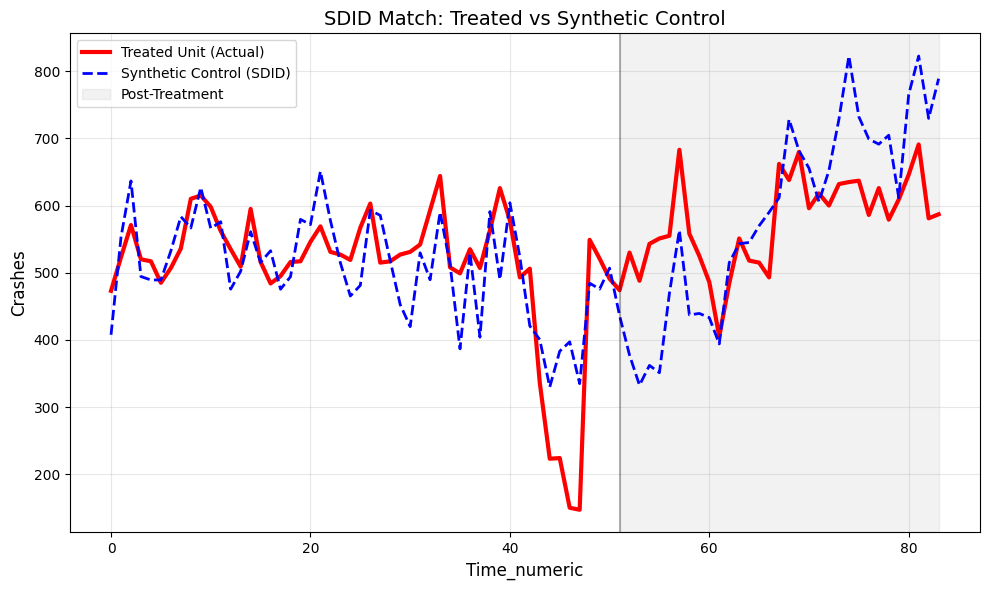

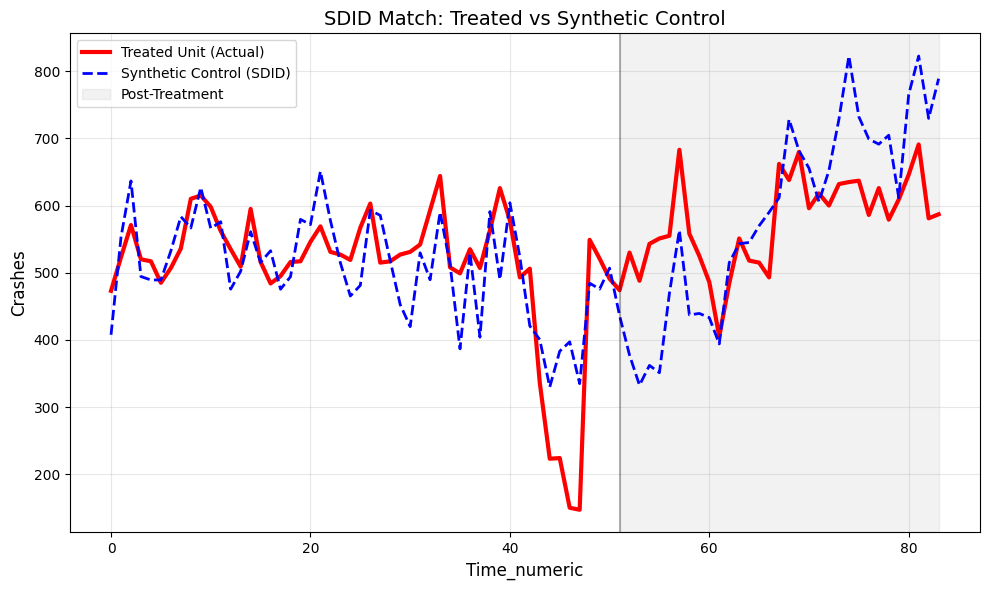

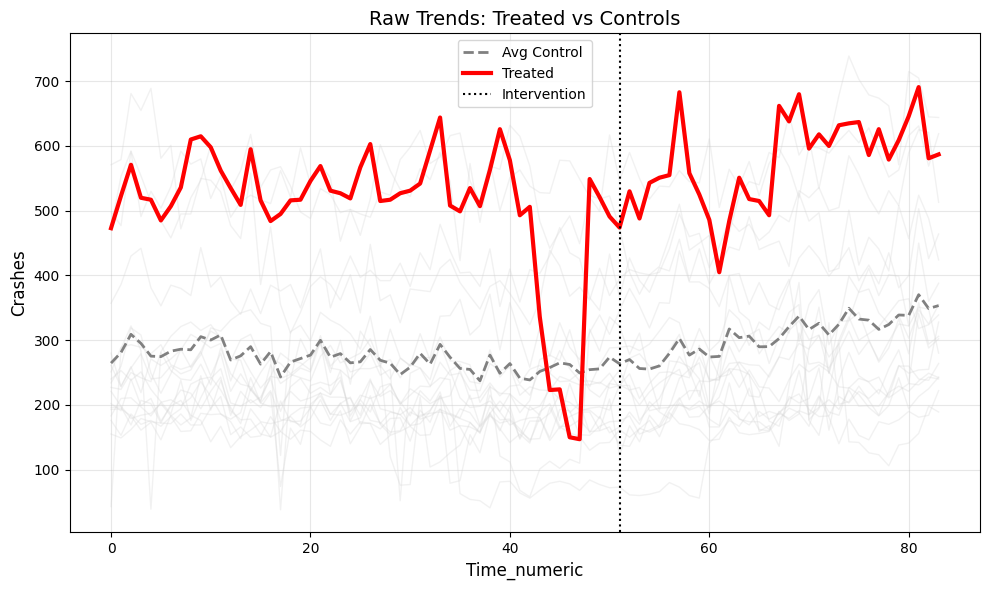

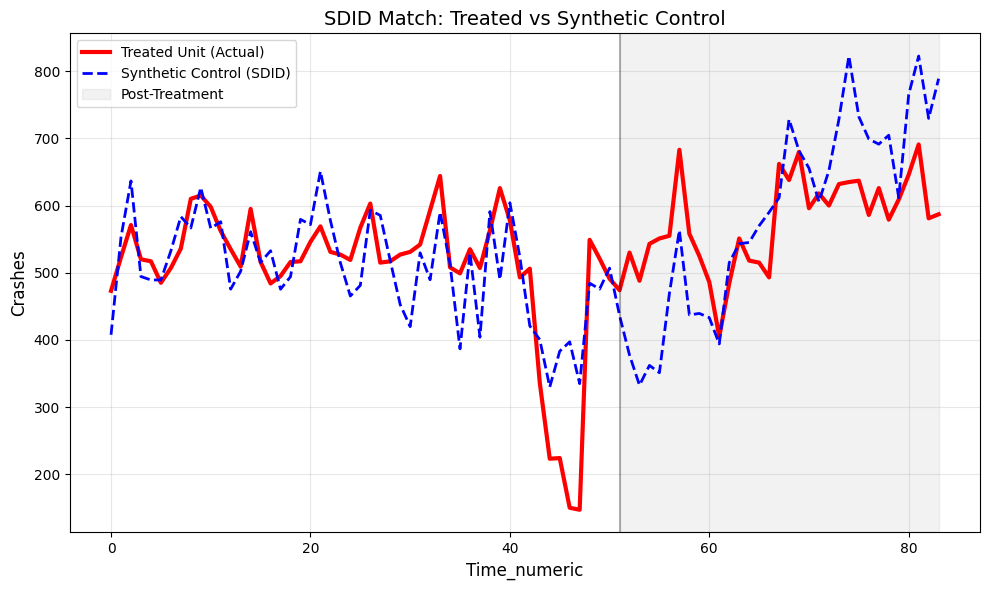

In [18]:
# Synthetic control vs actual SF trends
model.plot_synthetic_control()

# Raw trends for all cities
model.plot_raw_trends()

# print the full summary
model.summary()

model.plot_synthetic_control()

<class 'matplotlib.figure.Figure'>


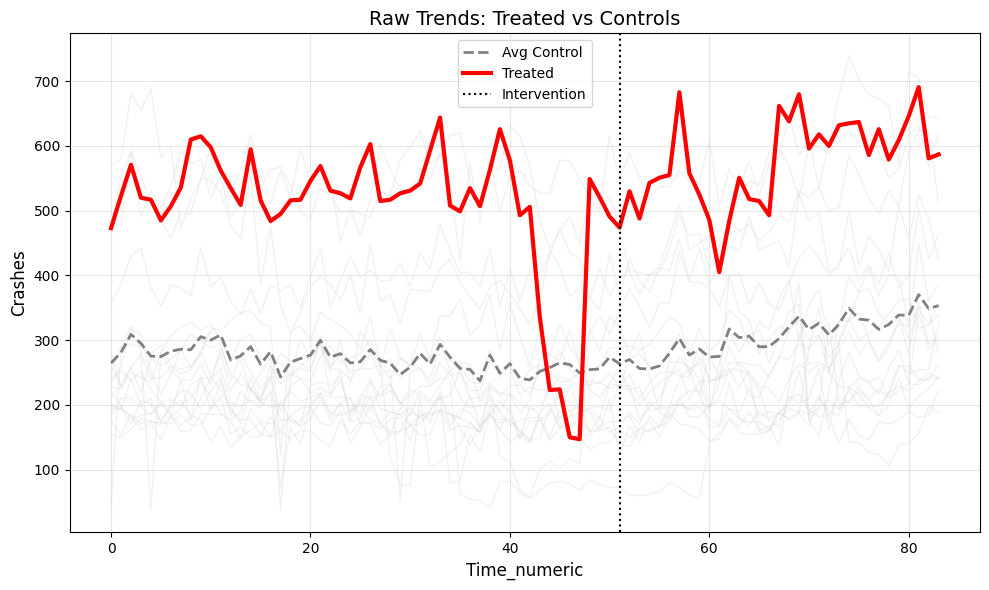

In [ ]:
result = model.plot_raw_trends()
print((result))

INFO:sdid.core:Creating synthetic control plot...


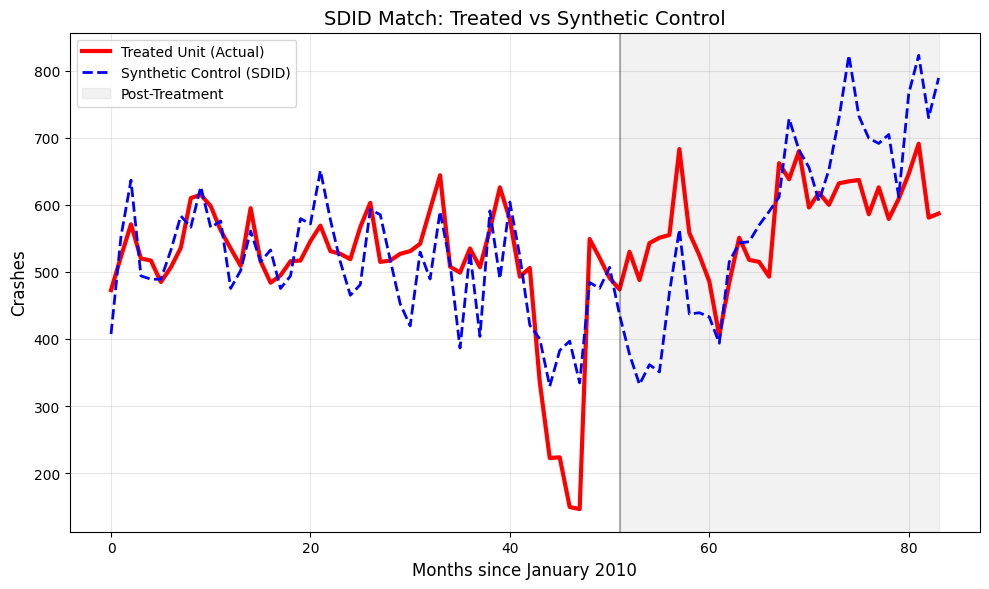

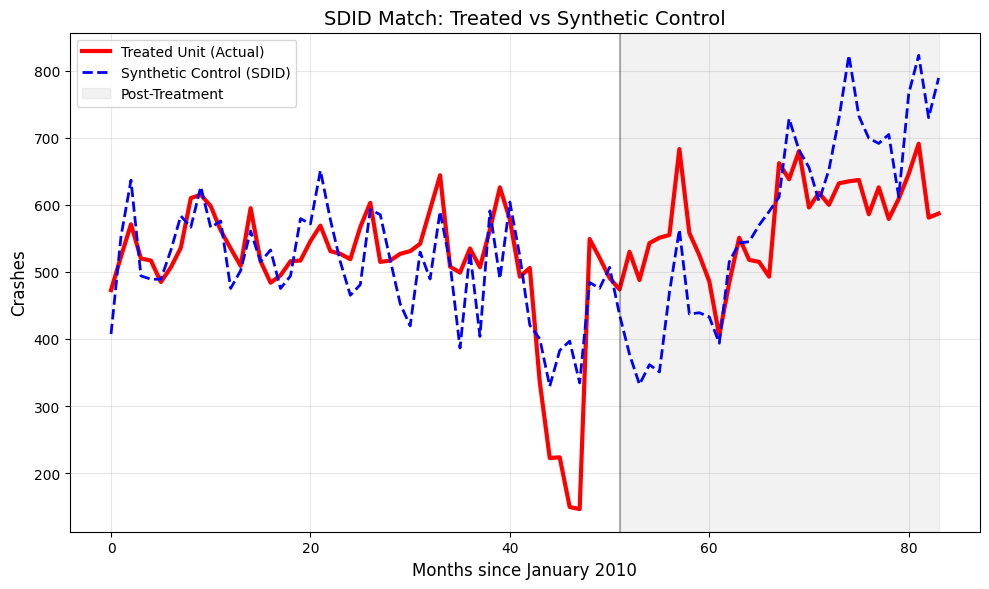

In [23]:
result2 = model.plot_synthetic_control()

for ax in result2.axes:
    ax.set_ylabel("Crashes")
    ax.set_xlabel("Months since January 2010")

result2

In [24]:
model.estimate_se(n_bootstrap=200, n_jobs=4)
print(model.summary(confidence_level = .95))

INFO:sdid.core:Estimating standard error with 200 bootstrap samples...
INFO:sdid.core:Data validated: 2 treated units, 17 controls, 51 pre-periods, 33 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core:Data validated: 2 treated units, 17 controls, 51 pre-periods, 33 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Unit regularization: 124.7236
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core:Unit regularization: 121.9898
INFO:sdid.core:Data validated: 2 treated units, 17 controls, 51 pre-periods, 33 post-periods
INFO:sdid.core:Starting SDID analysis...
INFO:sdid.core:Estimating unit weights...
INFO:sdid.core:Unit weights estimated: 6 units with non-zero weights
INFO:sdid.core:Unit intercept: -248.2481
INFO:sdid.core:Estimating time weights...
INFO:sdid.core:Time regularization: 51.9476
INFO:sdid.core:Unit regularization: 122.0843
INFO:sdid.core:Unit weights estimated: 8 units with non-zero weights
I

Synthetic Difference-in-Differences Results
Treatment Effect (ATT): 171.7879
Standard Error:        78.1205
95% Confidence Interval: [18.6746, 324.9012]
t-statistic:           2.1990
p-value:               0.0279
Control units used:    6
Time periods used:     0


In [25]:
model.get_weights_summary()

{'unit_weights':                 weight  rank
 Agency                      
 Long Beach    1.130991   1.0
 Pasadena      0.841860   2.0
 Garden Grove  0.521374   3.0
 Riverside     0.508788   4.0
 Fresno        0.289043   5.0
 Stockton      0.074993   6.0,
 'time_weights': Empty DataFrame
 Columns: [weight, rank]
 Index: []}